In [181]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import math
from scipy.stats import moment

He extraido varios espectros de Heave, Surge y Sway de forma manual en SeaFEM. Voy a agrupar todas las amplitudes en 3 dataframes, el mismo número de movimientos que estoy analizando

In [182]:
path = rf'D:\arturo_sim\simulaciones\acoplado\espectros'
movements = ['Heave','Surge','Sway']
dataframes_heave = {}
dataframes_surge = {}
dataframes_sway = {}

for mov in movements:
    direc = os.listdir(os.path.join(path,mov))
    for file in direc:
        file_path = os.path.join(path, mov, file)
        df = pd.read_excel(file_path, header=1).drop(0)

        # Almaceno los resultados del número de simulaciones empleado
        if mov == 'Heave':
            dataframes_heave[f'{file}'] = df
        elif mov == 'Surge':
            dataframes_surge[f'{file}'] = df
        else:
            dataframes_sway[f'{file}'] = df

In [183]:
dataframes_heave['oc4__Hs1__Tp2__dir1__1.xlsx']

,Frequencies),Amplitude
1,0.001221,0.000103
2,0.002441,0.000107
3,0.003662,0.000107
4,0.004883,0.000112
5,0.006104,0.000121
...,...,...
4092,4.995117,0.000021
4093,4.996338,0.000021
4094,4.997559,0.000021
4095,4.998779,0.000021


In [184]:
df_heave = pd.concat(dataframes_heave.values(), axis=1)
df_surge = pd.concat(dataframes_surge.values(), axis=1)
df_sway = pd.concat(dataframes_sway.values(), axis=1)

In [185]:
df_surge

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,...,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.001221,0.033272,0.001221,0.036576,0.001221,0.031510,0.001221,0.034849,0.001221,0.030763,...,0.001221,0.039391,0.001221,0.028638,0.001221,0.032087,0.001221,0.029900,0.001221,0.033217
2,0.002441,0.035605,0.002441,0.034914,0.002441,0.034181,0.002441,0.033715,0.002441,0.033645,...,0.002441,0.037237,0.002441,0.032214,0.002441,0.032251,0.002441,0.032776,0.002441,0.032377
3,0.003662,0.026814,0.003662,0.024267,0.003662,0.026069,0.003662,0.023820,0.003662,0.025837,...,0.003662,0.024930,0.003662,0.024989,0.003662,0.023474,0.003662,0.025224,0.003662,0.023083
4,0.004883,0.018362,0.004883,0.015885,0.004883,0.018022,0.004883,0.015827,0.004883,0.017819,...,0.004883,0.016503,0.004883,0.015914,0.004883,0.014137,0.004883,0.019262,0.004883,0.017280
5,0.006104,0.013490,0.006104,0.011310,0.006104,0.013321,0.006104,0.011389,0.006104,0.013478,...,0.006104,0.011943,0.006104,0.013676,0.006104,0.012201,0.006104,0.013485,0.006104,0.011772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000034,4.995117,0.000030,4.995117,0.000016,4.995117,0.000012,4.995117,0.000010,...,4.995117,0.000015,4.995117,0.000068,4.995117,0.000073,4.995117,0.000056,4.995117,0.000051
4093,4.996338,0.000034,4.996338,0.000030,4.996338,0.000016,4.996338,0.000012,4.996338,0.000010,...,4.996338,0.000015,4.996338,0.000068,4.996338,0.000073,4.996338,0.000056,4.996338,0.000051
4094,4.997559,0.000034,4.997559,0.000030,4.997559,0.000016,4.997559,0.000012,4.997559,0.000010,...,4.997559,0.000015,4.997559,0.000068,4.997559,0.000073,4.997559,0.000056,4.997559,0.000051
4095,4.998779,0.000035,4.998779,0.000030,4.998779,0.000016,4.998779,0.000012,4.998779,0.000010,...,4.998779,0.000015,4.998779,0.000068,4.998779,0.000073,4.998779,0.000056,4.998779,0.000051


In [186]:
df_sway

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,...,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.001221,0.030334,0.001221,0.032021,0.001221,0.031693,0.001221,0.033532,0.001221,0.031466,...,0.001221,0.032885,0.001221,0.032987,0.001221,0.034961,0.001221,0.028046,0.001221,0.029344
2,0.002441,0.014037,0.002441,0.008399,0.002441,0.016277,0.002441,0.010614,0.002441,0.015913,...,0.002441,0.009692,0.002441,0.018363,0.002441,0.012693,0.002441,0.009830,0.002441,0.004556
3,0.003662,0.006689,0.003662,0.001351,0.003662,0.008675,0.003662,0.003428,0.003662,0.008350,...,0.003662,0.003344,0.003662,0.010662,0.003662,0.005563,0.003662,0.003655,0.003662,0.003639
4,0.004883,0.004232,0.004883,0.000076,0.004883,0.005937,0.004883,0.002172,0.004883,0.005595,...,0.004883,0.001383,0.004883,0.007421,0.004883,0.003994,0.004883,0.002119,0.004883,0.003082
5,0.006104,0.003069,0.006104,0.000471,0.006104,0.004526,0.006104,0.001818,0.006104,0.004254,...,0.006104,0.000944,0.006104,0.006330,0.006104,0.004039,0.006104,0.003866,0.006104,0.004303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000002,4.995117,0.000005,4.995117,0.000019,4.995117,0.000012,4.995117,0.000009,...,4.995117,0.000052,4.995117,0.000015,4.995117,0.000009,4.995117,0.000076,4.995117,0.000082
4093,4.996338,0.000002,4.996338,0.000005,4.996338,0.000019,4.996338,0.000012,4.996338,0.000009,...,4.996338,0.000052,4.996338,0.000015,4.996338,0.000009,4.996338,0.000076,4.996338,0.000082
4094,4.997559,0.000002,4.997559,0.000005,4.997559,0.000019,4.997559,0.000012,4.997559,0.000009,...,4.997559,0.000052,4.997559,0.000015,4.997559,0.000009,4.997559,0.000076,4.997559,0.000082
4095,4.998779,0.000002,4.998779,0.000005,4.998779,0.000019,4.998779,0.000012,4.998779,0.000009,...,4.998779,0.000052,4.998779,0.000015,4.998779,0.000009,4.998779,0.000076,4.998779,0.000082


Como el rango de frecuencias es el mismo en todas las simulaciones, me cargo las columnas sobrantes

In [187]:
df_freq = df_surge.iloc[:,0]
df_surge = df_surge.drop(df_surge.filter(like='Frequencies)').columns, axis=1)
df_surge.insert(0,'Frequency',df_freq)

In [188]:
df_surge

,Frequency,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude,Amplitude
1,0.001221,0.033272,0.036576,0.031510,0.034849,0.030763,0.034123,0.031093,0.034430,0.029995,0.033380,0.036109,0.039391,0.028638,0.032087,0.029900,0.033217
2,0.002441,0.035605,0.034914,0.034181,0.033715,0.033645,0.033300,0.033795,0.033369,0.032627,0.032357,0.038216,0.037237,0.032214,0.032251,0.032776,0.032377
3,0.003662,0.026814,0.024267,0.026069,0.023820,0.025837,0.023754,0.025826,0.023631,0.026661,0.024541,0.027857,0.024930,0.024989,0.023474,0.025224,0.023083
4,0.004883,0.018362,0.015885,0.018022,0.015827,0.017819,0.015748,0.018065,0.015935,0.018195,0.016229,0.019338,0.016503,0.015914,0.014137,0.019262,0.017280
5,0.006104,0.013490,0.011310,0.013321,0.011389,0.013478,0.011670,0.013265,0.011394,0.013660,0.011942,0.014414,0.011943,0.013676,0.012201,0.013485,0.011772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4093,4.996338,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4094,4.997559,0.000034,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4095,4.998779,0.000035,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051


Les cambio el nombre de las amplitudes por el de los ficheros, que tienen la nomenclatura

In [189]:
path_surge = rf'D:\arturo_sim\simulaciones\acoplado\espectros\Surge'
lista_archivos = os.listdir(path_surge)

if len(lista_archivos) == (len(df_surge.columns) - 1):
    df_surge.columns = ['Frequency'] + lista_archivos

In [190]:
df_surge

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__2.xlsx,oc4__Hs1__Tp3__dir1__1.xlsx,oc4__Hs1__Tp3__dir1__2.xlsx,oc4__Hs1__Tp3__dir4__1.xlsx,oc4__Hs1__Tp3__dir4__2.xlsx,oc4__Hs1__Tp4__dir1__1.xlsx,oc4__Hs1__Tp4__dir1__2.xlsx,oc4__Hs1__Tp4__dir4__1.xlsx,oc4__Hs1__Tp4__dir4__2.xlsx,oc4__Hs2__Tp3__dir1__1.xlsx,oc4__Hs2__Tp3__dir1__2.xlsx,oc4__Hs2__Tp3__dir4__1.xlsx,oc4__Hs2__Tp3__dir4__2.xlsx
1,0.001221,0.033272,0.036576,0.031510,0.034849,0.030763,0.034123,0.031093,0.034430,0.029995,0.033380,0.036109,0.039391,0.028638,0.032087,0.029900,0.033217
2,0.002441,0.035605,0.034914,0.034181,0.033715,0.033645,0.033300,0.033795,0.033369,0.032627,0.032357,0.038216,0.037237,0.032214,0.032251,0.032776,0.032377
3,0.003662,0.026814,0.024267,0.026069,0.023820,0.025837,0.023754,0.025826,0.023631,0.026661,0.024541,0.027857,0.024930,0.024989,0.023474,0.025224,0.023083
4,0.004883,0.018362,0.015885,0.018022,0.015827,0.017819,0.015748,0.018065,0.015935,0.018195,0.016229,0.019338,0.016503,0.015914,0.014137,0.019262,0.017280
5,0.006104,0.013490,0.011310,0.013321,0.011389,0.013478,0.011670,0.013265,0.011394,0.013660,0.011942,0.014414,0.011943,0.013676,0.012201,0.013485,0.011772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4093,4.996338,0.000034,0.000030,0.000016,0.000012,0.000010,0.000015,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4094,4.997559,0.000034,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051
4095,4.998779,0.000035,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000073,0.000056,0.000051


In [191]:
df_surge.describe()

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__2.xlsx,oc4__Hs1__Tp3__dir1__1.xlsx,oc4__Hs1__Tp3__dir1__2.xlsx,oc4__Hs1__Tp3__dir4__1.xlsx,oc4__Hs1__Tp3__dir4__2.xlsx,oc4__Hs1__Tp4__dir1__1.xlsx,oc4__Hs1__Tp4__dir1__2.xlsx,oc4__Hs1__Tp4__dir4__1.xlsx,oc4__Hs1__Tp4__dir4__2.xlsx,oc4__Hs2__Tp3__dir1__1.xlsx,oc4__Hs2__Tp3__dir1__2.xlsx,oc4__Hs2__Tp3__dir4__1.xlsx,oc4__Hs2__Tp3__dir4__2.xlsx
count,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000
mean,2.500610,0.000349,0.000332,0.000215,0.000198,0.000388,0.000393,0.000279,0.000262,0.000565,0.000573,0.000356,0.000339,0.001115,0.001123,0.000610,0.000595
std,1.443552,0.002561,0.002547,0.001857,0.001842,0.003967,0.003956,0.002844,0.002838,0.005292,0.005283,0.003711,0.003700,0.011139,0.011133,0.007833,0.007833
min,0.001221,0.000034,0.000030,0.000016,0.000012,0.000010,0.000014,0.000033,0.000028,0.000022,0.000027,0.000019,0.000015,0.000068,0.000072,0.000056,0.000051
25%,1.250916,0.000037,0.000032,0.000018,0.000013,0.000011,0.000016,0.000036,0.000031,0.000024,0.000029,0.000021,0.000016,0.000074,0.000079,0.000061,0.000056
50%,2.500610,0.000049,0.000042,0.000023,0.000017,0.000014,0.000020,0.000046,0.000040,0.000032,0.000038,0.000027,0.000021,0.000096,0.000103,0.000079,0.000073
75%,3.750305,0.000091,0.000079,0.000043,0.000031,0.000026,0.000038,0.000086,0.000074,0.000059,0.000071,0.000051,0.000039,0.000178,0.000190,0.000147,0.000135
max,5.000000,0.087430,0.087365,0.067710,0.067758,0.118029,0.117789,0.121231,0.121437,0.133109,0.132918,0.117248,0.117412,0.339400,0.339131,0.352595,0.352776


## Representaciones del comportamiento de surge

veamos la diferencia entre un espectro en un caso saludable y en un caso con garreo

representación con dirección del oleaje a 0º

<Figure size 2000x1000 with 0 Axes>

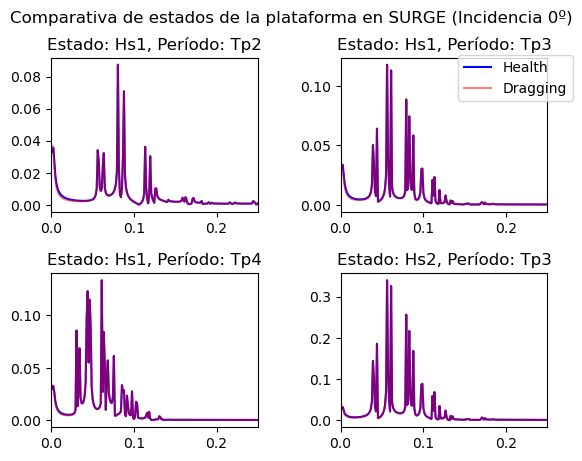

In [192]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SURGE (Incidencia 0º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

representación con dirección del oleaje a 60º

representación con dirección del oleaje a 90º

representación con dirección del oleaje a 120º

<Figure size 2000x1000 with 0 Axes>

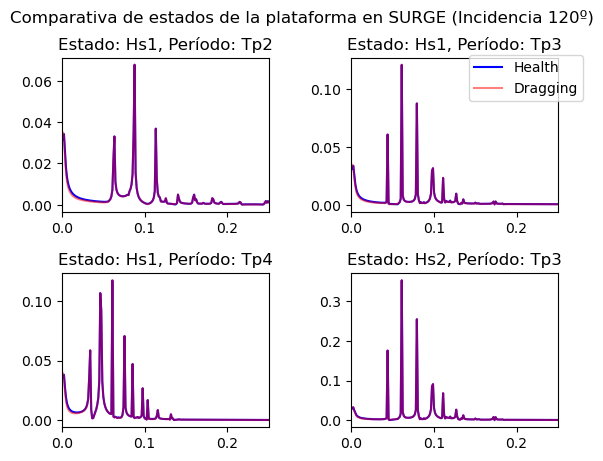

In [193]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp4__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_surge['Frequency'],df_surge['oc4__Hs2__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SURGE (Incidencia 120º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

representación con dirección del oleaje a 180º

## Representaciones del comportamiento de sway

In [194]:
df_freq = df_surge.iloc[:,0]
df_sway = df_sway.drop(df_sway.filter(like='Frequencies)').columns, axis=1)
df_sway.insert(0,'Frequency',df_freq)

In [195]:
path_sway = rf'D:\arturo_sim\simulaciones\acoplado\espectros\Sway'
lista_archivos = os.listdir(path_sway)

if len(lista_archivos) == (len(df_sway.columns) - 1):
    df_sway.columns = ['Frequency'] + lista_archivos

In [196]:
df_sway

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir4__1.xlsx,oc4__Hs1__Tp2__dir4__2.xlsx,oc4__Hs1__Tp3__dir1__1.xlsx,oc4__Hs1__Tp3__dir1__2.xlsx,oc4__Hs1__Tp3__dir4__1.xlsx,oc4__Hs1__Tp3__dir4__2.xlsx,oc4__Hs1__Tp4__dir1__1.xlsx,oc4__Hs1__Tp4__dir1__2.xlsx,oc4__Hs1__Tp4__dir4__1.xlsx,oc4__Hs1__Tp4__dir4__2.xlsx,oc4__Hs2__Tp3__dir1__1.xlsx,oc4__Hs2__Tp3__dir1__2.xlsx,oc4__Hs2__Tp3__dir4__1.xlsx,oc4__Hs2__Tp3__dir4__2.xlsx
1,0.001221,0.030334,0.032021,0.031693,0.033532,0.031466,0.033279,0.029728,0.031346,0.028588,0.030018,0.031089,0.032885,0.032987,0.034961,0.028046,0.029344
2,0.002441,0.014037,0.008399,0.016277,0.010614,0.015913,0.010245,0.013053,0.007452,0.010797,0.005246,0.015324,0.009692,0.018363,0.012693,0.009830,0.004556
3,0.003662,0.006689,0.001351,0.008675,0.003428,0.008350,0.003096,0.005891,0.000920,0.003954,0.002674,0.008715,0.003344,0.010662,0.005563,0.003655,0.003639
4,0.004883,0.004232,0.000076,0.005937,0.002172,0.005595,0.001813,0.003740,0.000927,0.003101,0.003543,0.005514,0.001383,0.007421,0.003994,0.002119,0.003082
5,0.006104,0.003069,0.000471,0.004526,0.001818,0.004254,0.001543,0.002944,0.001400,0.003222,0.003950,0.004224,0.000944,0.006330,0.004039,0.003866,0.004303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092,4.995117,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000046,0.000052,0.000015,0.000009,0.000076,0.000082
4093,4.996338,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000046,0.000052,0.000015,0.000009,0.000076,0.000082
4094,4.997559,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000045,0.000052,0.000015,0.000009,0.000076,0.000082
4095,4.998779,0.000002,0.000005,0.000019,0.000012,0.000009,0.000002,0.000023,0.000030,0.000032,0.000025,0.000045,0.000052,0.000015,0.000009,0.000076,0.000082


<Figure size 2000x1000 with 0 Axes>

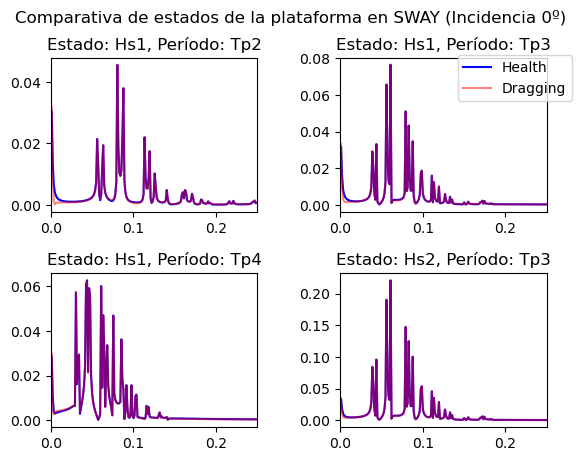

In [197]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir1__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir1__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SWAY (Incidencia 0º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

<Figure size 2000x1000 with 0 Axes>

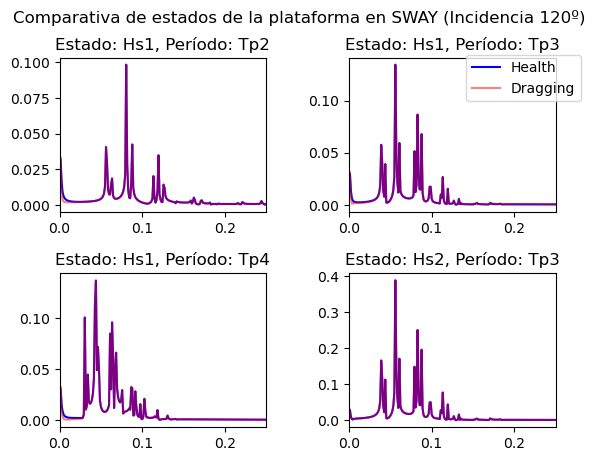

In [198]:
plt.figure(figsize=(20, 10))
fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
hs1_tp2, hs1_tp3, hs1_tp4, hs2_tp3 = axs.flatten()


hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp2.set_xlim(0,0.25)
hs1_tp2.set_title('Estado: Hs1, Período: Tp2')


hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp3.set_xlim(0,0.25)
hs1_tp3.set_title('Estado: Hs1, Período: Tp3')


hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir4__1.xlsx'], color = 'b', label = 'Health')
hs1_tp4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp4__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs1_tp4.set_xlim(0,0.25)
hs1_tp4.set_title('Estado: Hs1, Período: Tp4')


hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir4__1.xlsx'], color = 'b', label = 'Health')
hs2_tp3.plot(df_sway['Frequency'],df_sway['oc4__Hs2__Tp3__dir4__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
hs2_tp3.set_xlim(0,0.25)
hs2_tp3.set_title('Estado: Hs2, Período: Tp3')


fig.subplots_adjust(hspace=0.4, wspace=0.4)
fig.suptitle('Comparativa de estados de la plataforma en SWAY (Incidencia 120º)')
fig.legend(['Health', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

## Prueba con análisis no lineal

Como los espectros se mantienen iguales a pesar de mover el anchor point, veamos como se comporta en un análisis de segundo orden

In [199]:
path = rf'D:\arturo_sim\simulaciones\acoplado\espectros_no_lineal'
movements = ['Surge','Sway']
#dataframes_heave = {}
dataframes_surge_2 = {}
dataframes_sway_2 = {}

for mov in movements:
    direc = os.listdir(os.path.join(path,mov))
    for file in direc:
        file_path = os.path.join(path, mov, file)
        df = pd.read_excel(file_path, header=1).drop(0)

        # Almaceno los resultados del número de simulaciones empleado
        #if mov == 'Heave':
            #dataframes_heave[f'{file}'] = df
        if mov == 'Surge':
            dataframes_surge_2[f'{file}'] = df
        else:
            dataframes_sway_2[f'{file}'] = df

In [200]:
dataframes_surge_2['oc4__Hs1__Tp2__dir1__1.xlsx']

,Frequencies),Amplitude
1,0.001221,0.033272
2,0.002441,0.035605
3,0.003662,0.026814
4,0.004883,0.018362
5,0.006104,0.013490
...,...,...
4092,4.995117,0.000034
4093,4.996338,0.000034
4094,4.997559,0.000034
4095,4.998779,0.000035


In [201]:
df_surge_2 = pd.concat(dataframes_surge_2.values(), axis=1)
df_sway_2 = pd.concat(dataframes_sway_2.values(), axis=1)

In [202]:
df_freq = df_surge_2.iloc[:,0]
df_surge_2 = df_surge_2.drop(df_surge_2.filter(like='Frequencies)').columns, axis=1)
df_surge_2.insert(0,'Frequency',df_freq)

In [203]:
path_surge_2 = rf'D:\arturo_sim\simulaciones\acoplado\espectros_no_lineal\Surge'
lista_archivos = os.listdir(path_surge_2)

if len(lista_archivos) == (len(df_surge_2.columns) - 1):
    df_surge_2.columns = ['Frequency'] + lista_archivos

In [204]:
df_surge_2

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx
1,0.001221,0.033272,0.036576
2,0.002441,0.035605,0.034914
3,0.003662,0.026814,0.024267
4,0.004883,0.018362,0.015885
5,0.006104,0.013490,0.011310
...,...,...,...
4092,4.995117,0.000034,0.000030
4093,4.996338,0.000034,0.000030
4094,4.997559,0.000034,0.000030
4095,4.998779,0.000035,0.000030


Comparemos diferencias entre espectros saludables lineal y no lineal.

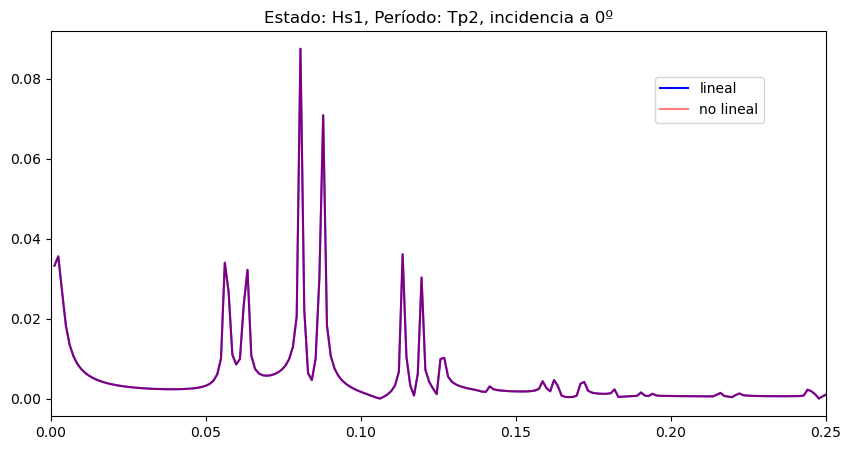

In [205]:
plt.figure(figsize=(10, 5))

plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'lineal')
plt.plot(df_surge_2['Frequency'],df_surge_2['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'r', label = 'no lineal',alpha=0.5)
plt.xlim(0,0.25)
plt.title('Estado: Hs1, Período: Tp2, incidencia a 0º')
plt.legend(['lineal', 'no lineal'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

Comparación de estados con surge

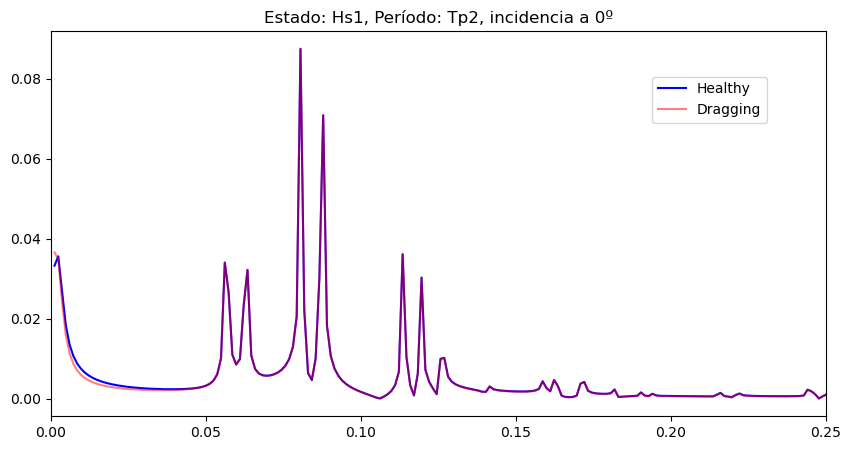

In [206]:
plt.figure(figsize=(10, 5))

plt.plot(df_surge_2['Frequency'],df_surge_2['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Healthy')
plt.plot(df_surge_2['Frequency'],df_surge_2['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
plt.xlim(0,0.25)
plt.title('Estado: Hs1, Período: Tp2, incidencia a 0º')
plt.legend(['Healthy', 'Dragging'], loc='upper center', bbox_to_anchor=(0.85, 0.9))

## Detección de límite del garreo

### Surge

Como probando con 5 m de desplazamiento no se han visto grandes cambios, vamos a detectar una distancia límite donde los espectros difieran con mayor claridad

In [254]:
path = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo'
movements = ['Surge','Sway']
dataframes_surge = {}
dataframes_sway = {}

for mov in movements:
    direc = os.listdir(os.path.join(path,mov))
    for file in direc:
        file_path = os.path.join(path, mov, file)
        df = pd.read_excel(file_path, header=1).drop(0)

        # Almaceno los resultados del número de simulaciones empleado
        if mov == 'Surge':
            dataframes_surge[f'{file}'] = df
        else:
            dataframes_sway[f'{file}'] = df

In [208]:
dataframes_surge['oc4__Hs1__Tp2__dir1__2.xlsx']

,Frequencies),Amplitude
1,0.002441,7.912032e-02
2,0.004883,3.725436e-02
3,0.007324,2.092640e-02
4,0.009766,1.454733e-02
5,0.012207,1.129185e-02
...,...,...
2044,4.990234,2.530248e-07
2045,4.992676,1.687390e-07
2046,4.995117,1.268861e-07
2047,4.997559,1.995568e-07


In [209]:
df_surge = pd.concat(dataframes_surge.values(), axis=1)
df_sway = pd.concat(dataframes_sway.values(), axis=1)

In [210]:
df_surge

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.002441,0.091913,0.002441,7.912032e-02,0.002441,0.087156,0.002441,0.162692,0.002441,0.208059,0.002441,0.131558,0.002441,0.061164
2,0.004883,0.033768,0.004883,3.725436e-02,0.004883,0.064765,0.004883,0.107065,0.004883,0.121588,0.004883,0.075295,0.004883,0.140842
3,0.007324,0.014195,0.007324,2.092640e-02,0.007324,0.043601,0.007324,0.072357,0.007324,0.081293,0.007324,0.049852,0.007324,0.110455
4,0.009766,0.007643,0.009766,1.454733e-02,0.009766,0.032668,0.009766,0.054361,0.009766,0.060900,0.009766,0.037204,0.009766,0.026779
5,0.012207,0.004829,0.012207,1.129185e-02,0.012207,0.026174,0.012207,0.043563,0.012207,0.048733,0.012207,0.029742,0.012207,0.033780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,0.000028,4.990234,2.530248e-07,4.990234,0.000058,4.990234,0.000124,4.990234,0.000143,4.990234,0.000070,4.990234,0.000164
2045,4.992676,0.000028,4.992676,1.687390e-07,4.992676,0.000058,4.992676,0.000124,4.992676,0.000143,4.992676,0.000068,4.992676,0.000163
2046,4.995117,0.000028,4.995117,1.268861e-07,4.995117,0.000058,4.995117,0.000124,4.995117,0.000143,4.995117,0.000069,4.995117,0.000165
2047,4.997559,0.000028,4.997559,1.995568e-07,4.997559,0.000058,4.997559,0.000124,4.997559,0.000143,4.997559,0.000070,4.997559,0.000164


In [211]:
df_sway

,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude,Frequencies),Amplitude
1,0.002441,0.059471,0.002441,3.058180e-02,0.002441,0.092018,0.002441,0.236142,0.002441,0.301286,0.002441,0.168987,0.002441,0.094013
2,0.004883,0.024559,0.004883,1.024009e-02,0.004883,0.056546,0.004883,0.121604,0.004883,0.137134,0.004883,0.052974,0.004883,0.259477
3,0.007324,0.013993,0.007324,6.034910e-03,0.007324,0.038851,0.007324,0.080665,0.007324,0.088459,0.007324,0.027633,0.007324,0.249548
4,0.009766,0.009582,0.009766,4.266991e-03,0.009766,0.029476,0.009766,0.060391,0.009766,0.065534,0.009766,0.018220,0.009766,0.161761
5,0.012207,0.007267,0.012207,3.318906e-03,0.012207,0.023720,0.012207,0.048285,0.012207,0.052136,0.012207,0.013552,0.012207,0.104616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,4.990234,0.000037,4.990234,2.766957e-07,4.990234,0.000080,4.990234,0.000173,4.990234,0.000186,4.990234,0.000032,4.990234,0.000314
2045,4.992676,0.000037,4.992676,3.328908e-07,4.992676,0.000080,4.992676,0.000173,4.992676,0.000186,4.992676,0.000032,4.992676,0.000313
2046,4.995117,0.000037,4.995117,2.865883e-07,4.995117,0.000080,4.995117,0.000173,4.995117,0.000186,4.995117,0.000032,4.995117,0.000312
2047,4.997559,0.000037,4.997559,1.022289e-07,4.997559,0.000080,4.997559,0.000173,4.997559,0.000186,4.997559,0.000032,4.997559,0.000314


In [212]:
df_freq = df_surge.iloc[:,0]
df_surge = df_surge.drop(df_surge.filter(like='Frequencies)').columns, axis=1)
df_surge.insert(0,'Frequency',df_freq)

In [213]:
path_surge = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo\Surge'
lista_archivos = os.listdir(path_surge)

if len(lista_archivos) == (len(df_surge.columns) - 1):
    df_surge.columns = ['Frequency'] + lista_archivos

In [214]:
df_surge

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir1__3.xlsx,oc4__Hs1__Tp2__dir1__4.xlsx,oc4__Hs1__Tp2__dir1__5.xlsx,oc4__Hs1__Tp2__dir1__6.xlsx,oc4__Hs1__Tp2__dir1__7.xlsx
1,0.002441,0.091913,7.912032e-02,0.087156,0.162692,0.208059,0.131558,0.061164
2,0.004883,0.033768,3.725436e-02,0.064765,0.107065,0.121588,0.075295,0.140842
3,0.007324,0.014195,2.092640e-02,0.043601,0.072357,0.081293,0.049852,0.110455
4,0.009766,0.007643,1.454733e-02,0.032668,0.054361,0.060900,0.037204,0.026779
5,0.012207,0.004829,1.129185e-02,0.026174,0.043563,0.048733,0.029742,0.033780
...,...,...,...,...,...,...,...,...
2044,4.990234,0.000028,2.530248e-07,0.000058,0.000124,0.000143,0.000070,0.000164
2045,4.992676,0.000028,1.687390e-07,0.000058,0.000124,0.000143,0.000068,0.000163
2046,4.995117,0.000028,1.268861e-07,0.000058,0.000124,0.000143,0.000069,0.000165
2047,4.997559,0.000028,1.995568e-07,0.000058,0.000124,0.000143,0.000070,0.000164


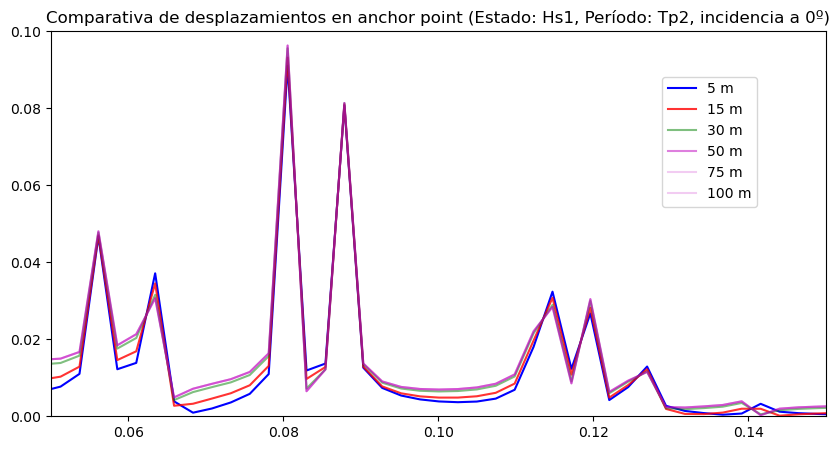

In [236]:
plt.figure(figsize=(10, 5))

plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'b', label = '5 m')
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = '15 m',alpha=0.5)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'g', label = '30 m',alpha=0.5)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '50 m',alpha=0.5)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '75 m',alpha=0.2)
plt.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '100 m',alpha=0.2)

plt.xlim(0.05,0.15)
plt.ylim(0,0.10)
plt.title('Comparativa de desplazamientos en anchor point (Estado: Hs1, Período: Tp2, incidencia a 0º)')
plt.legend(loc='upper center', bbox_to_anchor=(0.85, 0.9))

Comparativa de garreos con el caso saludable

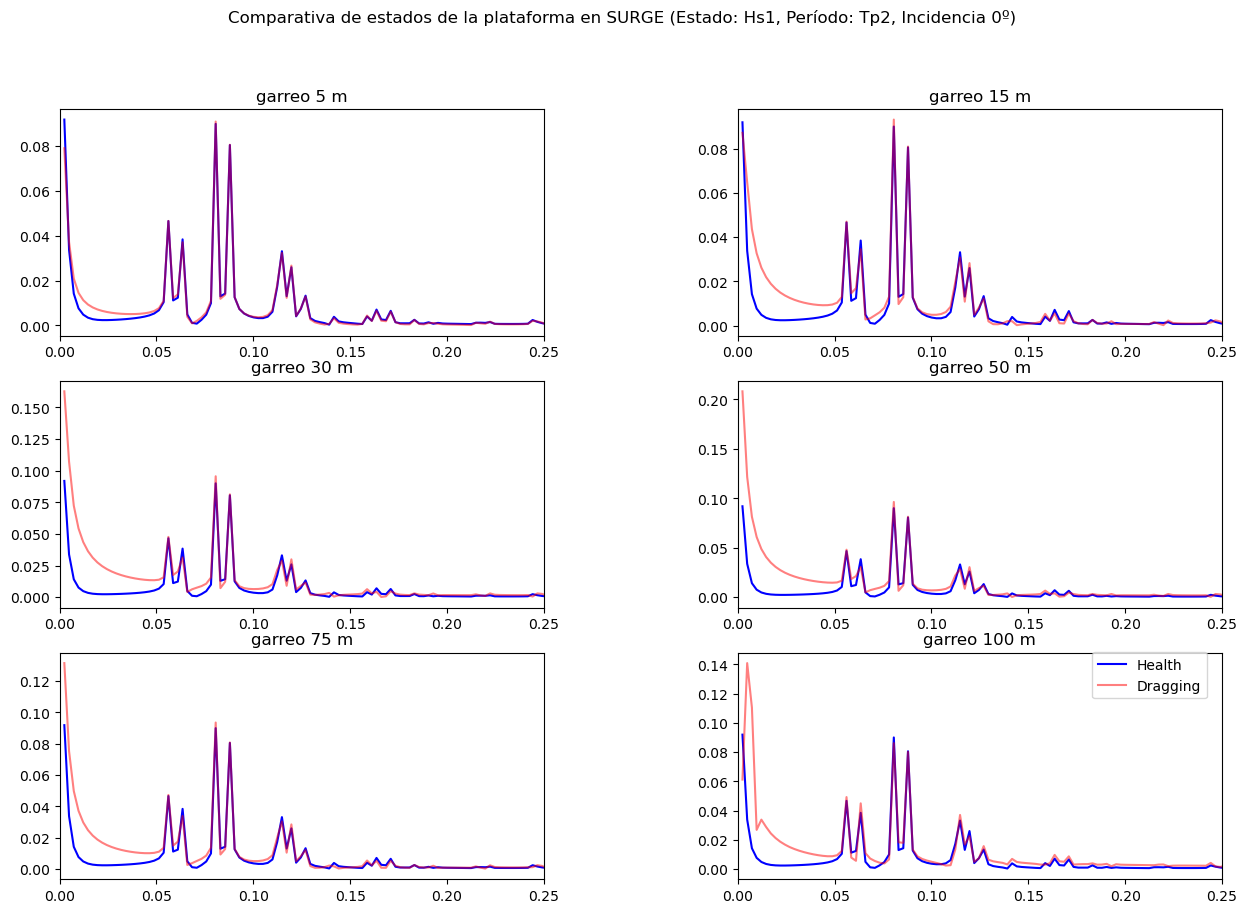

In [241]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()


garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo1.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')


garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo2.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')


garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo3.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')


garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo4.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')


garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo5.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo6.plot(df_surge['Frequency'],df_surge['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de estados de la plataforma en SURGE (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Health', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

Comparemos los momentos de orden 0, 2 y 4. Aumentando el orden de los momentos se pueden cuentificar mejor las diferencias.

In [288]:
columns = ['m2','m4']
stats = pd.DataFrame(columns=columns)
for col in df_surge.columns[1:]:
    m2 = moment(df_surge[col], moment=2)
    m4 = moment(df_surge[col], moment=4)

    stats.loc[col]=[m2,m4]

stats.index=['health','5','15','30','50','75','100']

In [289]:
stats

,m2,m4
health,0.000016,9.044403e-08
5,0.000015,7.694613e-08
15,0.000020,9.813199e-08
30,0.000038,4.794820e-07
50,0.000050,1.095766e-06
75,0.000026,2.230182e-07
100,0.000031,3.152440e-07


In [290]:
momentos = ['m2','m4']
m2_dif=[]
m4_dif=[]

for m in momentos:
    health = stats[m][0]
    for i in range(1,len(stats)):
        dif = abs(stats[m][i]-health)
        if m=='m2':
            m2_dif.append(dif)
        else:
            m4_dif.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_8404\2691464250.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_8404\2691464250.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats[m][i]-health)


In [291]:
m2_dif

[4.0273759897973653e-07,
 4.120987008095539e-06,
 2.2286018535377273e-05,
 3.42346902467154e-05,
 1.0454465708851405e-05,
 1.5306548393858267e-05]

In [292]:
m4_dif

[1.3497900107428237e-08,
 7.687954909762567e-09,
 3.890379227293679e-07,
 1.0053221917492553e-06,
 1.3257413815952556e-07,
 2.247999877865433e-07]

### Sway

In [256]:
df_freq = df_sway.iloc[:,0]
df_sway = df_sway.drop(df_sway.filter(like='Frequencies)').columns, axis=1)
df_sway.insert(0,'Frequency',df_freq)

ValueError: cannot insert Frequency, already exists

In [257]:
path_sway = rf'D:\arturo_sim\simulaciones\acoplado\analisis_limite_garreo\Sway'
lista_archivos = os.listdir(path_sway)

if len(lista_archivos) == (len(df_sway.columns) - 1):
    df_sway.columns = ['Frequency'] + lista_archivos

In [258]:
df_sway

,Frequency,oc4__Hs1__Tp2__dir1__1.xlsx,oc4__Hs1__Tp2__dir1__2.xlsx,oc4__Hs1__Tp2__dir1__3.xlsx,oc4__Hs1__Tp2__dir1__4.xlsx,oc4__Hs1__Tp2__dir1__5.xlsx,oc4__Hs1__Tp2__dir1__6.xlsx,oc4__Hs1__Tp2__dir1__7.xlsx
1,0.002441,0.059471,3.058180e-02,0.092018,0.236142,0.301286,0.168987,0.094013
2,0.004883,0.024559,1.024009e-02,0.056546,0.121604,0.137134,0.052974,0.259477
3,0.007324,0.013993,6.034910e-03,0.038851,0.080665,0.088459,0.027633,0.249548
4,0.009766,0.009582,4.266991e-03,0.029476,0.060391,0.065534,0.018220,0.161761
5,0.012207,0.007267,3.318906e-03,0.023720,0.048285,0.052136,0.013552,0.104616
...,...,...,...,...,...,...,...,...
2044,4.990234,0.000037,2.766957e-07,0.000080,0.000173,0.000186,0.000032,0.000314
2045,4.992676,0.000037,3.328908e-07,0.000080,0.000173,0.000186,0.000032,0.000313
2046,4.995117,0.000037,2.865883e-07,0.000080,0.000173,0.000186,0.000032,0.000312
2047,4.997559,0.000037,1.022289e-07,0.000080,0.000173,0.000186,0.000032,0.000314


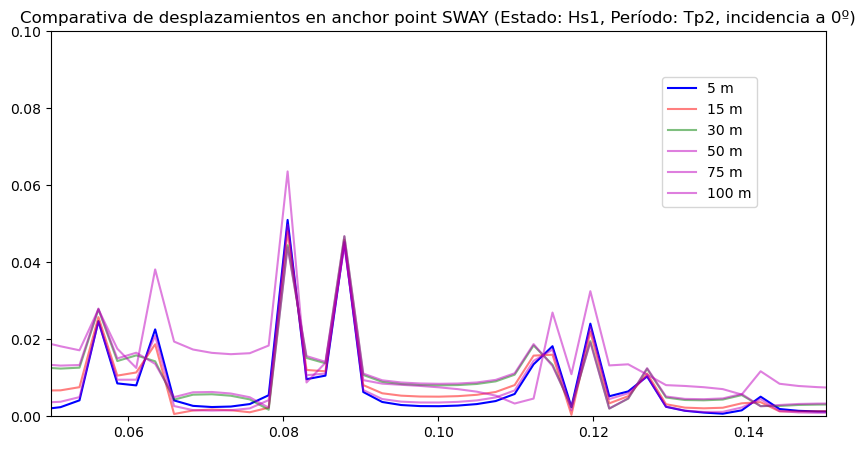

In [260]:
plt.figure(figsize=(10, 5))

plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'b', label = '5 m')
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = '15 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'g', label = '30 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'm', label = '50 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'm', label = '75 m',alpha=0.5)
plt.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'm', label = '100 m',alpha=0.5)

plt.xlim(0.05,0.15)
plt.ylim(0,0.10)
plt.title('Comparativa de desplazamientos en anchor point SWAY (Estado: Hs1, Período: Tp2, incidencia a 0º)')
plt.legend(loc='upper center', bbox_to_anchor=(0.85, 0.9))

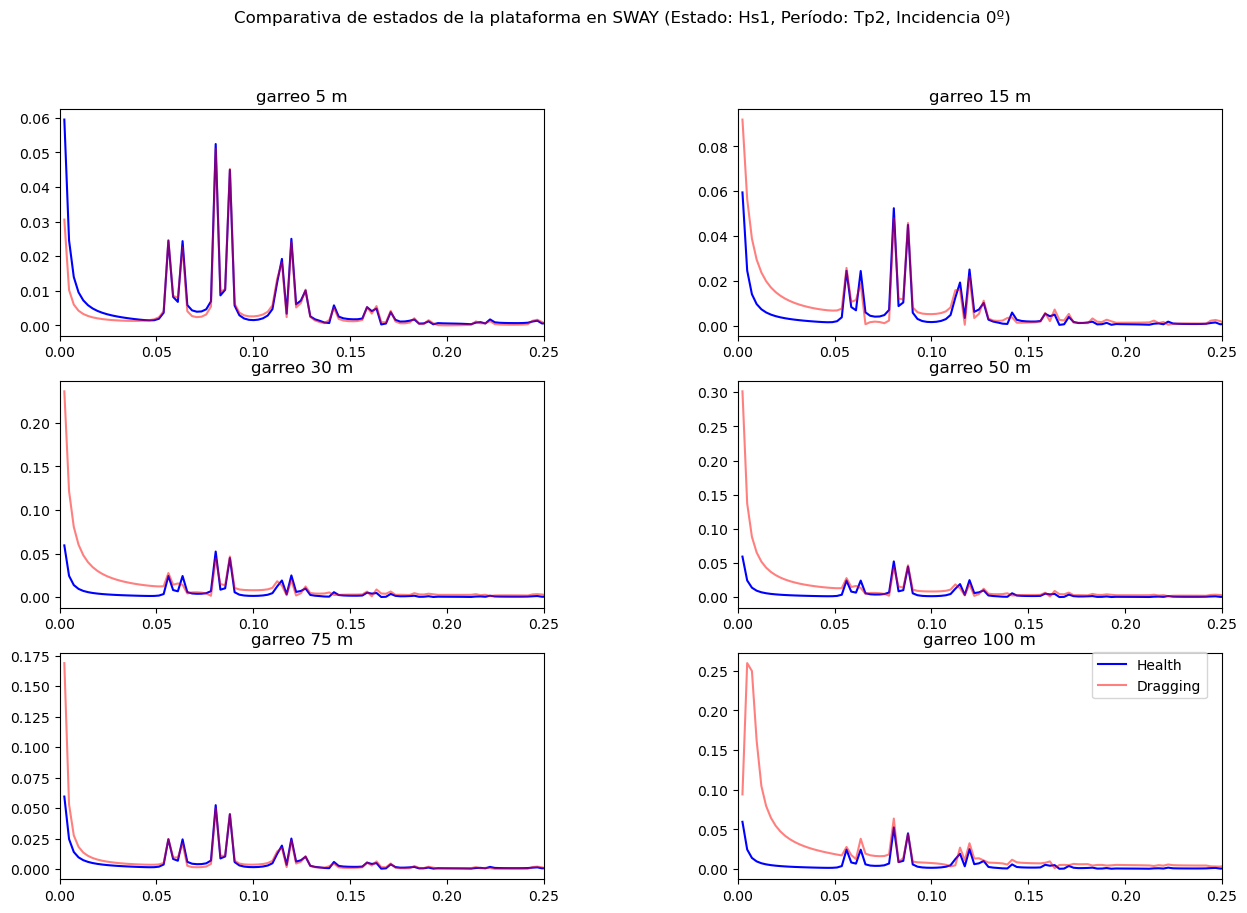

In [263]:
plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
garreo1 = plt.subplot(gs[0])
garreo2 = plt.subplot(gs[1])
garreo3 = plt.subplot(gs[2])
garreo4 = plt.subplot(gs[3])
garreo5 = plt.subplot(gs[4])
garreo6 = plt.subplot(gs[5])

#fig, axs = plt.subplots(nrows=2, ncols=2)

# Desempaqueta los ejes en variables individuales
#garreo1, garreo2, garreo3, garreo4 = axs.flatten()


garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo1.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__2.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo1.set_xlim(0,0.25)
garreo1.set_title('garreo 5 m')


garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo2.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__3.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo2.set_xlim(0,0.25)
garreo2.set_title('garreo 15 m')


garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo3.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__4.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo3.set_xlim(0,0.25)
garreo3.set_title('garreo 30 m')


garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo4.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__5.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo4.set_xlim(0,0.25)
garreo4.set_title('garreo 50 m')

garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo5.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__6.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo5.set_xlim(0,0.25)
garreo5.set_title('garreo 75 m')

garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__1.xlsx'], color = 'b', label = 'Health')
garreo6.plot(df_sway['Frequency'],df_sway['oc4__Hs1__Tp2__dir1__7.xlsx'], color = 'r', label = 'Dragging',alpha=0.5)
garreo6.set_xlim(0,0.25)
garreo6.set_title('garreo 100 m')


plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.suptitle('Comparativa de estados de la plataforma en SWAY (Estado: Hs1, Período: Tp2, Incidencia 0º)')
plt.legend(['Health', 'Dragging'], loc='center', bbox_to_anchor=(0.85, 0.9))

In [293]:
columns = ['m2','m4']
stats_sway = pd.DataFrame(columns=columns)
for col in df_sway.columns[1:]:
    m2 = moment(df_sway[col], moment=2)
    m4 = moment(df_sway[col], moment=4)

    stats_sway.loc[col]=[m2,m4]

stats_sway.index=['health','5','15','30','50','75','100']

In [294]:
stats_sway

,m2,m4
health,0.000006,1.227801e-08
5,0.000004,6.205526e-09
15,0.000012,4.559625e-08
30,0.000048,1.629776e-06
50,0.000069,4.177348e-06
75,0.000020,4.034942e-07
100,0.000104,4.452083e-06


In [295]:
momentos = ['m2','m4']
m2_dif_sway=[]
m4_dif_sway=[]

for m in momentos:
    health = stats_sway[m][0]
    for i in range(1,len(stats)):
        dif = abs(stats_sway[m][i]-health)
        if m=='m2':
            m2_dif_sway.append(dif)
        else:
            m4_dif_sway.append(dif)

C:\Users\naval\AppData\Local\Temp\ipykernel_8404\638759361.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  health = stats_sway[m][0]
C:\Users\naval\AppData\Local\Temp\ipykernel_8404\638759361.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  dif = abs(stats_sway[m][i]-health)


In [296]:
m2_dif_sway

[1.7712509705609265e-06,
 5.5362339921155845e-06,
 4.175274871235687e-05,
 6.247376181263839e-05,
 1.3667497347657064e-05,
 9.743280343713857e-05]

In [297]:
m4_dif_sway

[6.072489234362361e-09,
 3.331823831055061e-08,
 1.6174979399307408e-06,
 4.165070081338082e-06,
 3.9121615880527106e-07,
 4.439805319883873e-06]

vamos a representar la diferencia respecto al estado saludable de m2 y m4 de surge y sway

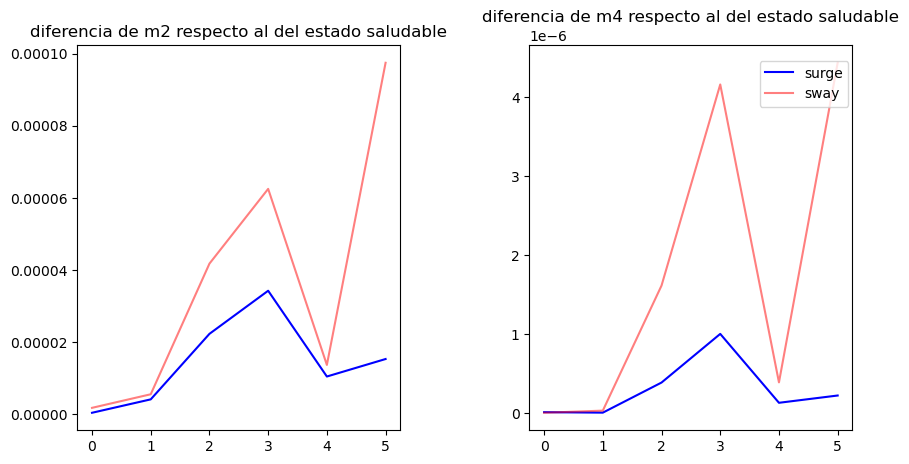

In [305]:
plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# Desempaqueta los ejes en variables individuales
a = plt.subplot(gs[0])
b = plt.subplot(gs[1])

a.plot(m2_dif, color = 'b', label = 'surge')
a.plot(m2_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
a.set_title('diferencia de m2 respecto al del estado saludable')


b.plot(m4_dif, color = 'b', label = 'surge')
b.plot(m4_dif_sway, color = 'r', label = 'sway',alpha=0.5)
#hs1_tp2.set_xlim(0,0.25)
b.set_title('diferencia de m4 respecto al del estado saludable')

plt.subplots_adjust(hspace=0.2, wspace=0.4)
plt.legend(['surge', 'sway'], loc='center', bbox_to_anchor=(0.85, 0.9))